# Supplementary Figure: Model Performance Comparison with Confidence Intervals

This notebook is a clean, single-purpose workflow to generate one visualization: model performance comparison across bin sizes with 95% confidence intervals.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import sem, t
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

FS_TITLE = 12
FS_SUBTITLE = 11
FS_LABEL = 12
FS_TICK = 11
FS_LEGEND = 10
FS_TEXT = 9

plt.style.use('default')
plt.rcParams.update({
    'font.size': FS_TEXT,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

base_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model')
results_dir = base_dir / 'results'
figures_dir = base_dir / 'figures'
figures_dir.mkdir(exist_ok=True)

candidate_files = [
    results_dir / 'evaluation_results_tuned' / 'bin-test_fold_final_predictions.csv',
]

predictions_file = next((p for p in candidate_files if p.exists()), None)
if predictions_file is None:
    raise FileNotFoundError('No suitable predictions CSV found for bin-test figure generation.')

df = pd.read_csv(predictions_file)
print(f'Loaded predictions from: {predictions_file}')
print(f"Rows: {len(df)} | unique n values: {sorted(df['n'].unique())}")

Loaded predictions from: /home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results_tuned/bin-test_fold_final_predictions.csv
Rows: 871200 | unique n values: [np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18), np.int64(20), np.int64(22), np.int64(24), np.int64(26), np.int64(28), np.int64(30)]


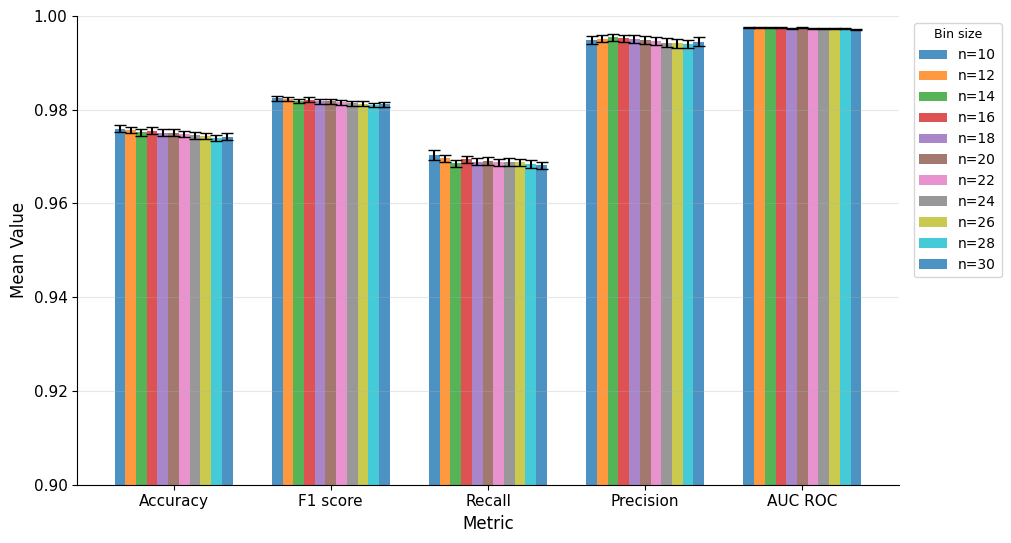

Saved figure to: /home/tobamo/analize/project-tobamo/analysis/model/figures/Figure_Supp4_BinPerformance_ConfidenceIntervals.png
Analyzed n values: [np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18), np.int64(20), np.int64(22), np.int64(24), np.int64(26), np.int64(28), np.int64(30)]


In [6]:
# Compute per-(random_seed, n) metrics
metrics_rows = []
group_cols = ['random_seed', 'n']

for (random_seed, n_value), grp in df.groupby(group_cols):
    y_true = grp['ground_truth']
    y_score = grp['prob_1']

    # If explicit predictions are absent, use the row-level threshold when available.
    if 'predicted_class' in grp.columns:
        y_pred = grp['predicted_class']
    elif 'threshold' in grp.columns:
        y_pred = (y_score >= grp['threshold']).astype(int)
    else:
        y_pred = (y_score >= 0.5).astype(int)

    metrics_rows.append({
        'random_seed': random_seed,
        'n': n_value,
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'auc_roc': roc_auc_score(y_true, y_score),
    })

metrics_df = pd.DataFrame(metrics_rows)

# Summarize metrics with 95% confidence intervals per n
confidence_level = 0.95
summary_rows = []
for n_value, grp in metrics_df.groupby('n'):
    for metric in ['accuracy', 'f1_score', 'recall', 'precision', 'auc_roc']:
        vals = grp[metric].to_numpy()
        mean = vals.mean()
        std = vals.std(ddof=1) if len(vals) > 1 else 0.0
        se = sem(vals) if len(vals) > 1 else 0.0
        h = se * t.ppf((1 + confidence_level) / 2, len(vals) - 1) if len(vals) > 1 else 0.0
        summary_rows.append({
            'n': n_value,
            'metric': metric,
            'mean': mean,
            'std': std,
            'ci_lower': mean - h,
            'ci_upper': mean + h,
        })

summary_df = pd.DataFrame(summary_rows)

# Prepare arrays for grouped CI barplot
metrics_order = ['accuracy', 'f1_score', 'recall', 'precision', 'auc_roc']
metric_labels = ['Accuracy', 'F1 score', 'Recall', 'Precision', 'AUC ROC']
bins = sorted(summary_df['n'].unique())

means = np.array([summary_df[summary_df['n'] == n_value]['mean'].values for n_value in bins])
ci_lowers = np.array([summary_df[summary_df['n'] == n_value]['ci_lower'].values for n_value in bins])
ci_uppers = np.array([summary_df[summary_df['n'] == n_value]['ci_upper'].values for n_value in bins])
lower_err = means - ci_lowers
upper_err = ci_uppers - means

x = np.arange(len(metrics_order))
width = 0.75 / len(bins)

fig, ax = plt.subplots(figsize=(12, 5.5))
for i, n_value in enumerate(bins):
    ax.bar(
        x + i * width,
        means[i],
        width,
        yerr=[lower_err[i], upper_err[i]],
        capsize=4,
        alpha=0.8,
        label=f'n={n_value}',
    )

ax.set_xticks(x + width * (len(bins) - 1) / 2)
ax.set_xticklabels(metric_labels, fontsize=FS_TICK)
ax.set_xlabel('Metric', fontsize=FS_LABEL)
ax.set_ylabel('Mean Value', fontsize=FS_LABEL)
ax.set_ylim(0.90, 1.0)
ax.tick_params(axis='y', labelsize=FS_TICK)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=FS_LEGEND, title='Bin size')

plt.tight_layout(rect=[0, 0, 0.85, 1])
output_path = figures_dir / 'Figure_Supp4_BinPerformance_ConfidenceIntervals.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

print(f'Saved figure to: {output_path}')
print(f'Analyzed n values: {bins}')